# Zadanie 6: Model PINN (Physics-Informed Neural Network)

W tym zadaniu stworzymy model PINN (Physics-Informed Neural Network) dla naszego równania reakcji-dyfuzji.
Model ten będzie uczył się rozwiązania $u(x,t)$ korzystając z:
1.  **Danych symulacyjnych (zasymilowanych)** - punktów pomiarowych z "rzeczywistości" (wygenerowanych przez solver PDE).
2.  **Wiedzy fizycznej (równania PDE)** - minimalizacji residuum równania różniczkowego w losowych punktach kolokacji.

Porównamy wyniki predykcji PINN z oryginalną symulacją PDE oraz modelem surogatowym ODE.

In [12]:
import sys
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.interpolate import griddata

# Dodanie ścieżki do zad2
sys.path.append(os.path.abspath(os.path.join('..', 'zad2')))

# Ustawienie ziarna i urządzenia
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Parametry fizyczne (takie same jak w poprzednich zadaniach)
PARAMS = {
    'D': 0.1,
    'p': 0.01,
    'q': 1.0
}
T_END = 5.0
NX = 100
DT = 1e-3

Using device: cuda


In [13]:
# --- Generowanie Danych Ground Truth (PDE) ---

def generate_pde_data():
    """Generuje pełne rozwiązanie PDE jako Ground Truth."""
    try:
        from solvers import _neumann_laplacian, reaction, initial_condition
        import scipy.sparse as sp
        import scipy.sparse.linalg as spla
        
        # Parametry
        nx = NX
        dt = DT
        tend = T_END
        D = PARAMS['D']
        p = PARAMS['p']
        q = PARAMS['q']
        
        dx = 1.0 / (nx - 1)
        x = np.linspace(0, 1, nx)
        u = initial_condition(nx, dx, kind='gaussian')
        
        A = _neumann_laplacian(nx, dx)
        
        # Crank-Nicolson matrices
        M_l = sp.eye(nx) - 0.5 * dt * D * A
        M_r = sp.eye(nx) + 0.5 * dt * D * A
        
        nsteps = int(np.ceil(tend / dt))
        
        # Zbieramy wyniki
        u_all = [u.copy()]
        t_all = [0.0]
        
        current_t = 0.0
        for n in range(nsteps):
            Ru = reaction(u, p, q)
            rhs = M_r.dot(u) + dt * Ru
            u = spla.spsolve(M_l, rhs)
            current_t += dt
            
            # Zapisujemy co np. 10 kroków, żeby nie mieć za dużo danych (opcjonalne, ale dobre dla pamięci)
            # Tutaj zapiszemy wszystko lub co któryś krok
            if (n + 1) % 10 == 0:
                u_all.append(u.copy())
                t_all.append(current_t)
                
        u_matrix = np.array(u_all).T # (NX, NT)
        t_vector = np.array(t_all)
        
        return x, t_vector, u_matrix
        
    except ImportError as e:
        print(f"Błąd importu solvera: {e}. Używam uproszczonej generacji.")
        return None, None, None

x_true, t_true, u_true = generate_pde_data()

if x_true is not None:
    print(f"Wygenerowano dane PDE. Kształt u_true: {u_true.shape}, t_true: {t_true.shape}")
    
    # Przygotowanie danych treningowych dla PINN
    # Tworzymy siatkę (x, t)
    # Uwaga: t_true może mieć inny rozmiar niż u_true.shape[1] jeśli coś poszło nie tak, ale tutaj powinno być ok.
    
    X, T = np.meshgrid(x_true, t_true) # X, T shape: (NT, NX)
    
    # Spłaszczamy do formatu (N, 2) -> (x, t) i (N, 1) -> u
    X_flat = X.flatten()[:, None]
    T_flat = T.flatten()[:, None]
    u_flat = u_true.T.flatten()[:, None] # u_true.T ma kształt (NT, NX)
    
    # Wybieramy losowe punkty "pomiarowe" (Data Loss)
    # Np. 2000 punktów z całej domeny
    N_data = 2000
    idx = np.random.choice(X_flat.shape[0], N_data, replace=False)
    
    X_train = np.hstack((X_flat[idx], T_flat[idx]))
    u_train = u_flat[idx]
    
    # Punkty kolokacji (Physics Loss) - gęstsza siatka lub losowe w domenie
    N_collocation = 10000
    X_collocation = np.random.uniform(0, 1, (N_collocation, 1))
    T_collocation = np.random.uniform(0, T_END, (N_collocation, 1))
    XT_collocation = np.hstack((X_collocation, T_collocation))
    
    # Konwersja na tensory
    X_u_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    u_train_tensor = torch.tensor(u_train, dtype=torch.float32).to(device)
    X_f_train = torch.tensor(XT_collocation, dtype=torch.float32).to(device)
    
    print(f"Dane treningowe: {X_u_train.shape}, Punkty kolokacji: {X_f_train.shape}")
else:
    print("Nie udało się wygenerować danych.")

Wygenerowano dane PDE. Kształt u_true: (100, 501), t_true: (501,)
Dane treningowe: torch.Size([2000, 2]), Punkty kolokacji: torch.Size([10000, 2])


Rozpoczynam trening PINN...
Epoch 500/5000, Loss: 0.000186 (Data: 0.000101, Phy: 0.000085)
Epoch 500/5000, Loss: 0.000186 (Data: 0.000101, Phy: 0.000085)
Epoch 1000/5000, Loss: 0.000106 (Data: 0.000065, Phy: 0.000040)
Epoch 1000/5000, Loss: 0.000106 (Data: 0.000065, Phy: 0.000040)
Epoch 1500/5000, Loss: 0.000059 (Data: 0.000047, Phy: 0.000012)
Epoch 1500/5000, Loss: 0.000059 (Data: 0.000047, Phy: 0.000012)
Epoch 2000/5000, Loss: 0.000047 (Data: 0.000042, Phy: 0.000005)
Epoch 2000/5000, Loss: 0.000047 (Data: 0.000042, Phy: 0.000005)
Epoch 2500/5000, Loss: 0.000045 (Data: 0.000041, Phy: 0.000004)
Epoch 2500/5000, Loss: 0.000045 (Data: 0.000041, Phy: 0.000004)
Epoch 3000/5000, Loss: 0.000045 (Data: 0.000041, Phy: 0.000004)
Epoch 3000/5000, Loss: 0.000045 (Data: 0.000041, Phy: 0.000004)
Epoch 3500/5000, Loss: 0.000044 (Data: 0.000041, Phy: 0.000004)
Epoch 3500/5000, Loss: 0.000044 (Data: 0.000041, Phy: 0.000004)
Epoch 4000/5000, Loss: 0.000105 (Data: 0.000092, Phy: 0.000013)
Epoch 4000/500

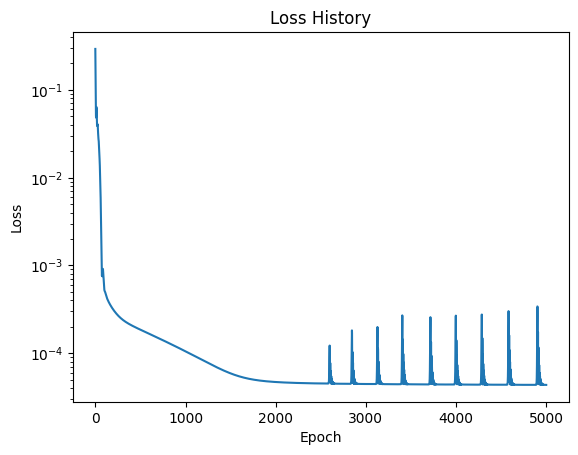

In [14]:
# --- Definicja Modelu PINN ---

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Prosta sieć MLP: wejście (x, t) -> wyjście u
        self.net = nn.Sequential(
            nn.Linear(2, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1)
        )
        
    def forward(self, x, t):
        # Łączymy x i t w jeden tensor wejściowy
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

def physics_loss(model, x, t, params):
    """Oblicza residuum równania PDE."""
    # Włączamy śledzenie gradientów dla wejścia
    x.requires_grad = True
    t.requires_grad = True
    
    u = model(x, t)
    
    # Obliczamy pochodne cząstkowe
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    D = params['D']
    p = params['p']
    q = params['q']
    
    # Równanie: u_t = D*u_xx + (p + q*u)*(1 - u)
    # Residuum: f = u_t - D*u_xx - (p + q*u)*(1 - u)
    f = u_t - D * u_xx - (p + q * u) * (1 - u)
    
    return torch.mean(f ** 2)

# Inicjalizacja modelu
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Pętla treningowa
epochs = 5000
loss_history = []

print("Rozpoczynam trening PINN...")
start_time = time.time()

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. Data Loss (MSE na punktach pomiarowych)
    # Rozdzielamy X_u_train na x i t
    x_data = X_u_train[:, 0:1]
    t_data = X_u_train[:, 1:2]
    u_pred = model(x_data, t_data)
    loss_data = torch.mean((u_pred - u_train_tensor) ** 2)
    
    # 2. Physics Loss (Residuum PDE w punktach kolokacji)
    x_col = X_f_train[:, 0:1]
    t_col = X_f_train[:, 1:2]
    loss_phy = physics_loss(model, x_col, t_col, PARAMS)
    
    # Całkowita strata
    loss = loss_data + loss_phy # Można dodać wagi, np. 1.0 * loss_data + 0.1 * loss_phy
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f} (Data: {loss_data.item():.6f}, Phy: {loss_phy.item():.6f})")

train_time = time.time() - start_time
print(f"Trening zakończony w {train_time:.2f}s")

plt.figure()
plt.plot(loss_history)
plt.yscale('log')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig('loss_history.png')
plt.show()

PINN Evaluation: MAE = 0.002412, RMSE = 0.007519


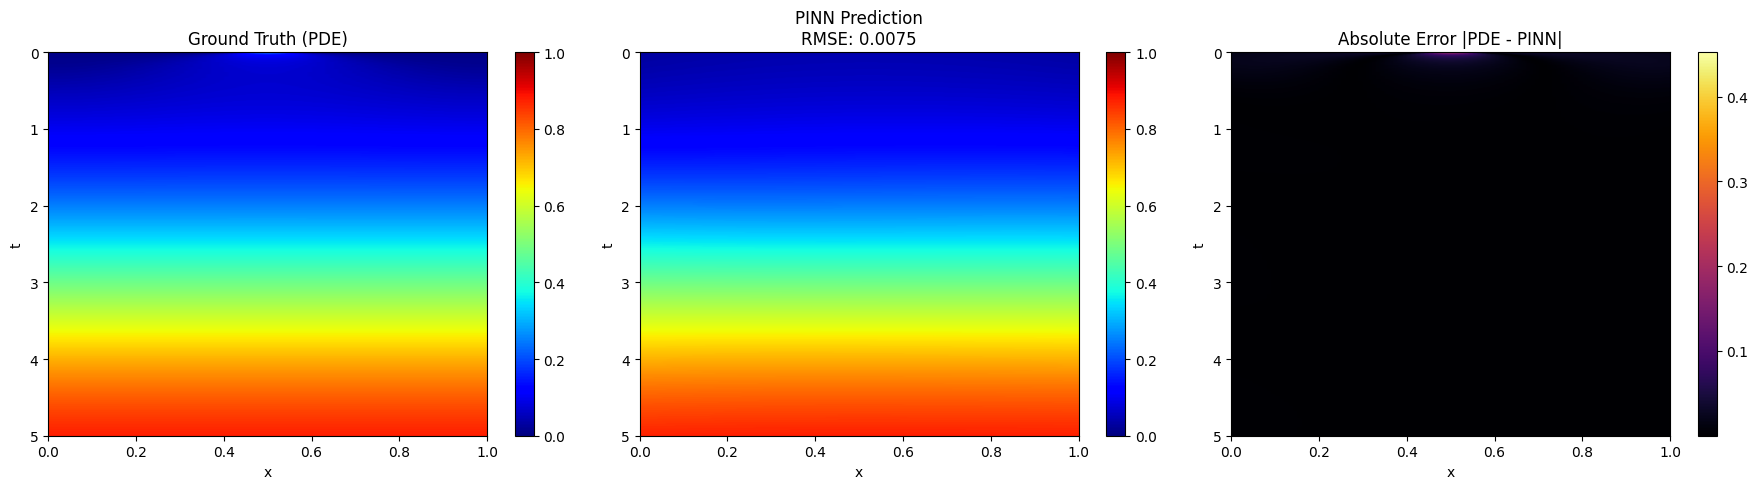

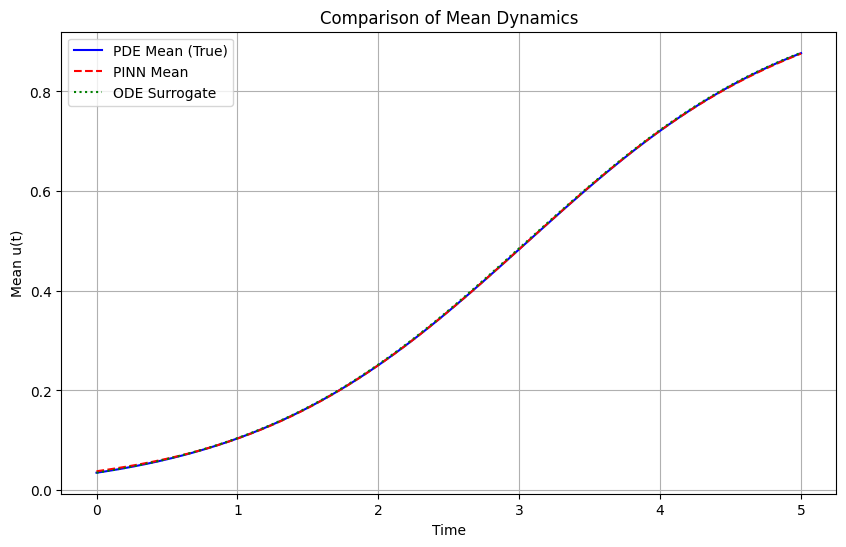

In [15]:
# --- Ewaluacja i Porównanie ---

# Generujemy predykcje na pełnej siatce
X_grid, T_grid = np.meshgrid(x_true, t_true)
X_flat_eval = X_grid.flatten()[:, None]
T_flat_eval = T_grid.flatten()[:, None]

x_eval_tensor = torch.tensor(X_flat_eval, dtype=torch.float32).to(device)
t_eval_tensor = torch.tensor(T_flat_eval, dtype=torch.float32).to(device)

with torch.no_grad():
    u_pred_flat = model(x_eval_tensor, t_eval_tensor).cpu().numpy()

u_pred_grid = u_pred_flat.reshape(X_grid.shape) # (NT, NX)

# Obliczamy błędy
abs_error = np.abs(u_true.T - u_pred_grid)
mae = np.mean(abs_error)
rmse = np.sqrt(np.mean(abs_error ** 2))

print(f"PINN Evaluation: MAE = {mae:.6f}, RMSE = {rmse:.6f}")

# --- Model ODE (Surogatowy) ---
# Rozwiązujemy ODE dla porównania
def ode_func(t, U):
    return (PARAMS['p'] + PARAMS['q'] * U) * (1 - U)

u0_mean = np.mean(u_true[:, 0]) # Średnia z warunku początkowego
sol_ode = torch.tensor(0) # Placeholder
from scipy.integrate import solve_ivp
sol_ode = solve_ivp(ode_func, [t_true[0], t_true[-1]], [u0_mean], t_eval=t_true)
u_ode = sol_ode.y.T # (NT, 1)

# --- Wizualizacja ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Ground Truth
im1 = axes[0].imshow(u_true.T, extent=[0, 1, T_END, 0], aspect='auto', cmap='jet', vmin=0, vmax=1)
axes[0].set_title('Ground Truth (PDE)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
plt.colorbar(im1, ax=axes[0])

# 2. PINN Prediction
im2 = axes[1].imshow(u_pred_grid, extent=[0, 1, T_END, 0], aspect='auto', cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f'PINN Prediction\nRMSE: {rmse:.4f}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
plt.colorbar(im2, ax=axes[1])

# 3. Absolute Error
im3 = axes[2].imshow(abs_error, extent=[0, 1, T_END, 0], aspect='auto', cmap='inferno')
axes[2].set_title('Absolute Error |PDE - PINN|')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig('pinn_results_heatmap.png')
plt.show()

# Porównanie w czasie (średnia przestrzenna)
u_pinn_mean = np.mean(u_pred_grid, axis=1)
u_true_mean = np.mean(u_true.T, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(t_true, u_true_mean, 'b-', label='PDE Mean (True)')
plt.plot(t_true, u_pinn_mean, 'r--', label='PINN Mean')
plt.plot(t_true, u_ode, 'g:', label='ODE Surrogate')
plt.title('Comparison of Mean Dynamics')
plt.xlabel('Time')
plt.ylabel('Mean u(t)')
plt.legend()
plt.grid(True)
plt.savefig('pinn_vs_pde_vs_ode.png')
plt.show()